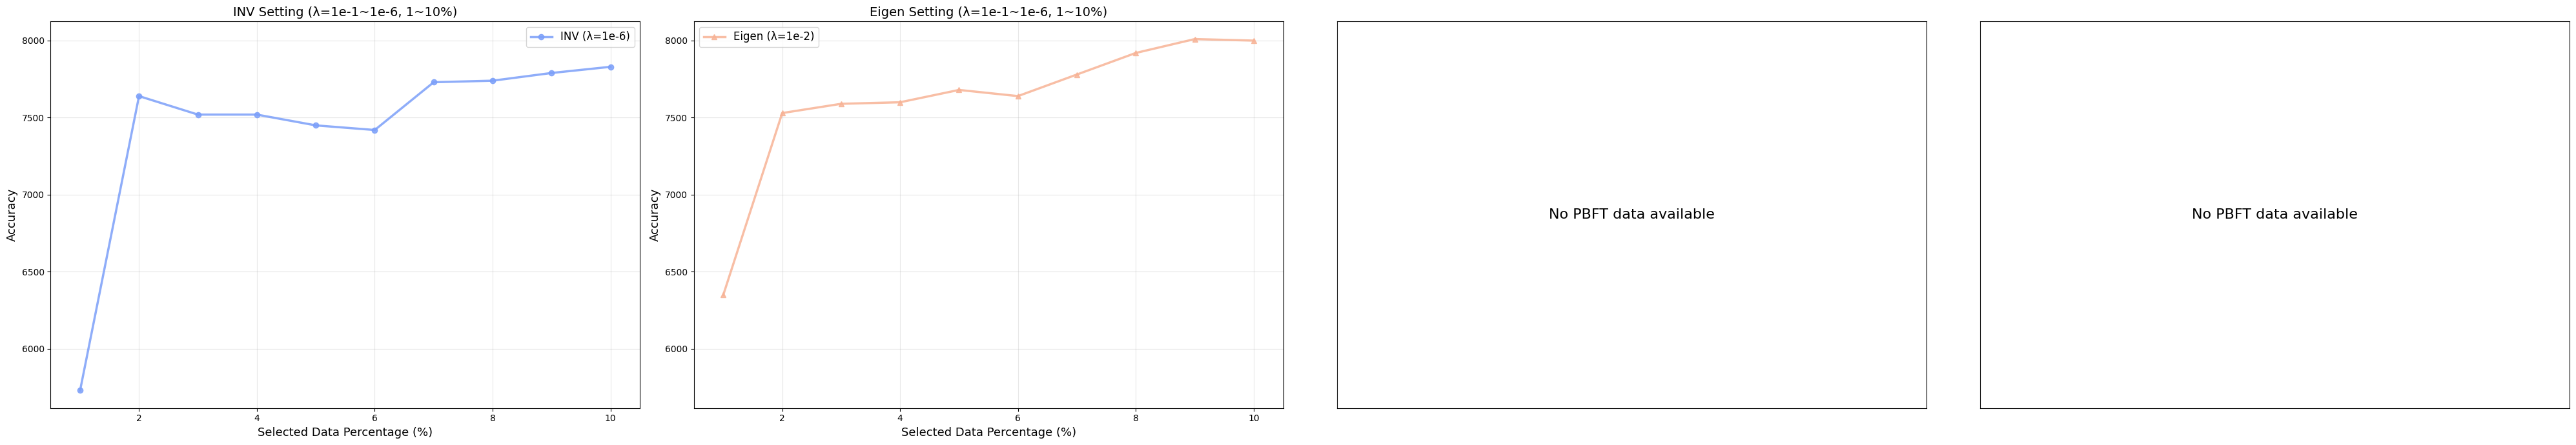

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
rank = 10
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [5730, 7640, 7520, 7520, 7450, 7420, 7730, 7740, 7790, 7830, 7750, 7980, 7990, 7940, 7900, 8010, 8090, 8100, 8080, 8130, 8140, 8070, 8060, 8070, 8070, 8100, 8110, 8100, 8130, 8110, 8100, 8120, 8150, 8190, 8200, 8170, 8130, 8200, 8190, 8190, 8150, 8140, 8150, 8190, 8200, 8180, 8190, 8150, 8170, 8230, 8200, 8180, 8160, 8160, 8190, 8230, 8190, 8180, 8190, 8240, 8250, 8260, 8190, 8200, 8220, 8270, 8280, 8220, 8250, 8240, 8300, 8270, 8270, 8330, 8260, 8250, 8220, 8270, 8290, 8300, 8290, 8310, 8320, 8320, 8270, 8240, 8220, 8220, 8270, 8240, 8180, 8220, 8110, 8150, 8130, 8110, 8070, 7990, 7880, 7820] 
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [6350, 7530, 7590, 7600, 7680, 7640, 7780, 7920, 8010, 8000, 7950, 8020, 8040, 7970, 8000, 7990, 8010, 8030, 8010, 8100, 8120, 8150, 8080, 8070, 8060, 8100, 8090, 8120, 8080, 8080, 8050, 8050, 8060, 8090, 8040, 8080, 8110, 8060, 8080, 8070, 8110, 8140, 8160, 8140, 8150, 8180, 8170, 8190, 8170, 8190, 8170, 8220, 8180, 8200, 8160, 8200, 8210, 8220, 8250, 8230, 8240, 8250, 8250, 8230, 8200, 8190, 8190, 8140, 8140, 8160, 8150, 8160, 8150, 8160, 8150, 8220, 8210, 8240, 8200, 8180, 8230, 8260, 8220, 8200, 8170, 8180, 8230, 8230, 8220, 8210, 8200, 8210, 8110, 8110, 8100, 8100, 8090, 8030, 8070, 8100]
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [5850, 7120, 7010, 7170, 7360, 7350, 7280, 7290, 7420, 7110, 7270, 7240, 7320, 7350, 7320, 7360, 7270, 7280, 7270, 7310, 7310, 7300, 7400, 7430, 7450, 7380, 7490, 7530, 7460, 7460, 7460, 7440, 7510, 7580, 7600, 7550, 7640, 7710, 7680, 7630, 7720, 7780, 7810, 7740, 7750, 7720, 7700, 7770, 7760, 7720, 7630, 7670, 7690, 7680, 7720, 7800, 7830, 7800, 7910, 7840, 7840, 7830, 7830, 7830, 7860, 7840, 7760, 7820, 7810, 7920, 7960, 7950, 7880, 7960, 7920, 7930, 7960, 7930, 7970, 7990, 7990, 7970, 7960, 7880, 7960, 7940, 7950, 7910, 7870, 7790, 7840, 7730, 7780, 7820, 7820, 7850, 7790, 7840, 7900, 7820]  
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [5990, 7090, 6900, 6680, 6520, 6870, 7140, 6890, 6980, 6590, 6530, 6780, 6610, 6540, 6520, 6470, 6560, 6600, 6560, 6590, 6680, 6980, 7060, 7070, 7070, 7170, 7240, 7370, 7430, 7480, 7570, 7610, 7740, 7820, 7800, 7840, 7870, 7930, 7890, 7980, 7890, 7950, 7940, 7920, 7910, 7880, 7840, 7820, 7850, 7890, 7870, 7930, 7930, 7950, 7920, 7970, 7860, 7880, 7860, 7930, 7920, 7920, 7910, 7920, 7940, 7940, 7930, 7960, 7970, 8010, 7980, 8000, 8000, 7980, 8010, 7960, 7970, 7940, 7940, 7930, 7990, 8020, 8030, 8040, 8010, 8020, 8060, 8040, 8020, 8010, 8000, 8050, 8010, 8030, 8060, 8030, 8030, 8090, 8070, 8100]
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

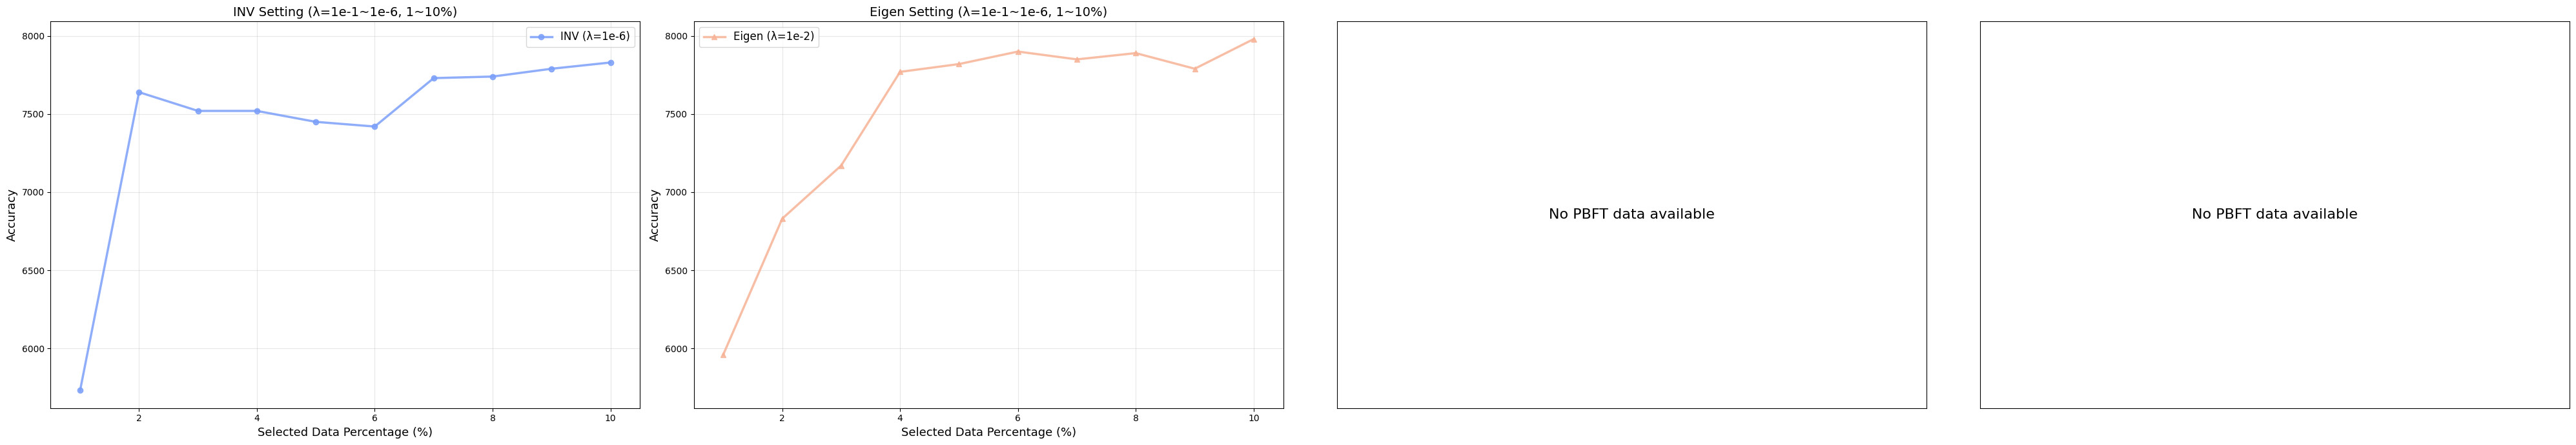

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
rank = 20
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [5730, 7640, 7520, 7520, 7450, 7420, 7730, 7740, 7790, 7830, 7750, 7980, 7990, 7940, 7900, 8010, 8090, 8100, 8080, 8130, 8140, 8070, 8060, 8070, 8070, 8100, 8110, 8100, 8130, 8110, 8100, 8120, 8150, 8190, 8200, 8170, 8130, 8200, 8190, 8190, 8150, 8140, 8150, 8190, 8200, 8180, 8190, 8150, 8170, 8230, 8200, 8180, 8160, 8160, 8190, 8230, 8190, 8180, 8190, 8240, 8250, 8260, 8190, 8200, 8220, 8270, 8280, 8220, 8250, 8240, 8300, 8270, 8270, 8330, 8260, 8250, 8220, 8270, 8290, 8300, 8290, 8310, 8320, 8320, 8270, 8240, 8220, 8220, 8270, 8240, 8180, 8220, 8110, 8150, 8130, 8110, 8070, 7990, 7880, 7820] 
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [5960, 6830, 7170, 7770, 7820, 7900, 7850, 7890, 7790, 7980, 7900, 7900, 7950, 8050, 8170, 8120, 8060, 8080, 7990, 8100, 8060, 8040, 8020, 8030, 8070, 8130, 8160, 8110, 8110, 8140, 8210, 8180, 8110, 8200, 8210, 8220, 8200, 8160, 8180, 8190, 8160, 8160, 8200, 8250, 8250, 8260, 8260, 8230, 8300, 8320, 8300, 8320, 8230, 8220, 8250, 8250, 8210, 8230, 8220, 8270, 8260, 8230, 8280, 8250, 8290, 8350, 8300, 8300, 8350, 8300, 8330, 8330, 8310, 8290, 8340, 8260, 8260, 8250, 8250, 8250, 8230, 8230, 8290, 8270, 8250, 8250, 8230, 8230, 8250, 8170, 8220, 8190, 8180, 8180, 8170, 8170, 8160, 8150, 8080, 8080]
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [5850, 7120, 7010, 7170, 7360, 7350, 7280, 7290, 7420, 7110, 7270, 7240, 7320, 7350, 7320, 7360, 7270, 7280, 7270, 7310, 7310, 7300, 7400, 7430, 7450, 7380, 7490, 7530, 7460, 7460, 7460, 7440, 7510, 7580, 7600, 7550, 7640, 7710, 7680, 7630, 7720, 7780, 7810, 7740, 7750, 7720, 7700, 7770, 7760, 7720, 7630, 7670, 7690, 7680, 7720, 7800, 7830, 7800, 7910, 7840, 7840, 7830, 7830, 7830, 7860, 7840, 7760, 7820, 7810, 7920, 7960, 7950, 7880, 7960, 7920, 7930, 7960, 7930, 7970, 7990, 7990, 7970, 7960, 7880, 7960, 7940, 7950, 7910, 7870, 7790, 7840, 7730, 7780, 7820, 7820, 7850, 7790, 7840, 7900, 7820]  
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [6040, 7000, 6820, 6820, 6630, 6840, 6920, 6880, 6900, 6610, 6730, 6650, 6610, 6580, 6580, 6580, 6490, 6330, 6490, 6410, 6480, 6540, 6590, 6850, 6780, 6790, 6960, 6990, 6970, 6960, 7070, 7070, 7140, 7170, 7210, 7300, 7320, 7340, 7500, 7590, 7470, 7560, 7610, 7600, 7610, 7580, 7580, 7590, 7610, 7580, 7710, 7620, 7620, 7680, 7670, 7700, 7690, 7720, 7750, 7720, 7790, 7730, 7690, 7760, 7790, 7760, 7720, 7830, 7890, 7940, 7880, 7980, 8010, 8060, 7980, 7960, 7960, 7960, 7950, 8030, 8090, 8060, 8050, 7990, 8030, 7990, 8010, 8060, 8080, 8040, 8020, 8060, 8070, 8120, 8140, 8130, 8170, 8110, 8080, 8080]
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

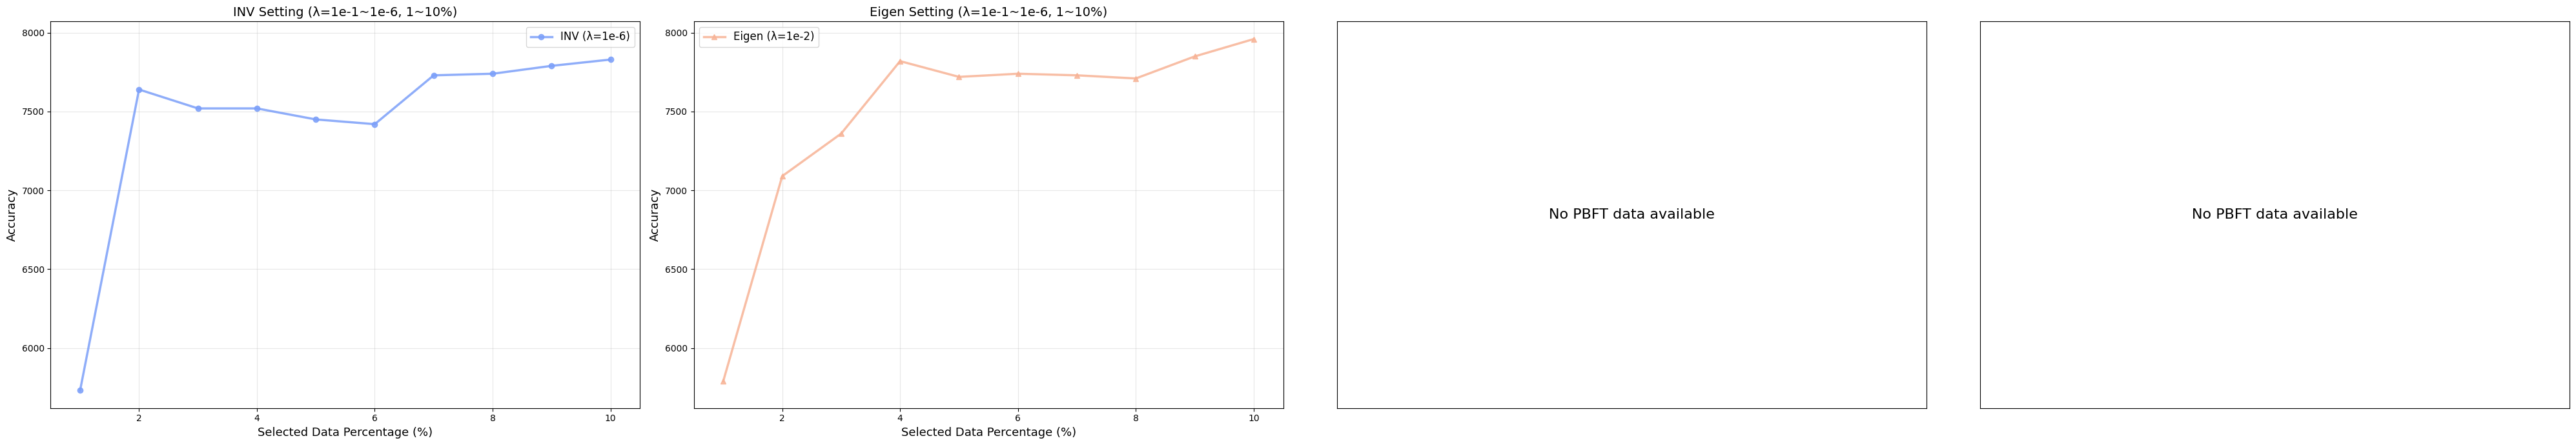

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [5730, 7640, 7520, 7520, 7450, 7420, 7730, 7740, 7790, 7830, 7750, 7980, 7990, 7940, 7900, 8010, 8090, 8100, 8080, 8130, 8140, 8070, 8060, 8070, 8070, 8100, 8110, 8100, 8130, 8110, 8100, 8120, 8150, 8190, 8200, 8170, 8130, 8200, 8190, 8190, 8150, 8140, 8150, 8190, 8200, 8180, 8190, 8150, 8170, 8230, 8200, 8180, 8160, 8160, 8190, 8230, 8190, 8180, 8190, 8240, 8250, 8260, 8190, 8200, 8220, 8270, 8280, 8220, 8250, 8240, 8300, 8270, 8270, 8330, 8260, 8250, 8220, 8270, 8290, 8300, 8290, 8310, 8320, 8320, 8270, 8240, 8220, 8220, 8270, 8240, 8180, 8220, 8110, 8150, 8130, 8110, 8070, 7990, 7880, 7820] 
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [5790, 7090, 7360, 7820, 7720, 7740, 7730, 7710, 7850, 7960, 7980, 7960, 7940, 7980, 8070, 8110, 8120, 8090, 8090, 8180, 8130, 8100, 8070, 8120, 8090, 8130, 8080, 8060, 8050, 8080, 8110, 8140, 8140, 8210, 8230, 8270, 8240, 8230, 8250, 8200, 8220, 8190, 8190, 8200, 8310, 8230, 8260, 8250, 8240, 8230, 8180, 8200, 8200, 8180, 8230, 8250, 8250, 8250, 8220, 8270, 8270, 8290, 8330, 8290, 8330, 8330, 8290, 8340, 8350, 8330, 8370, 8380, 8400, 8380, 8350, 8330, 8340, 8370, 8360, 8370, 8370, 8420, 8420, 8390, 8330, 8350, 8340, 8360, 8320, 8240, 8260, 8300, 8330, 8320, 8230, 8270, 8230, 8180, 8150, 8140]
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [5850, 7120, 7010, 7170, 7360, 7350, 7280, 7290, 7420, 7110, 7270, 7240, 7320, 7350, 7320, 7360, 7270, 7280, 7270, 7310, 7310, 7300, 7400, 7430, 7450, 7380, 7490, 7530, 7460, 7460, 7460, 7440, 7510, 7580, 7600, 7550, 7640, 7710, 7680, 7630, 7720, 7780, 7810, 7740, 7750, 7720, 7700, 7770, 7760, 7720, 7630, 7670, 7690, 7680, 7720, 7800, 7830, 7800, 7910, 7840, 7840, 7830, 7830, 7830, 7860, 7840, 7760, 7820, 7810, 7920, 7960, 7950, 7880, 7960, 7920, 7930, 7960, 7930, 7970, 7990, 7990, 7970, 7960, 7880, 7960, 7940, 7950, 7910, 7870, 7790, 7840, 7730, 7780, 7820, 7820, 7850, 7790, 7840, 7900, 7820]  
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [6030, 7200, 6960, 6910, 6870, 7000, 6920, 7020, 6850, 6760, 6800, 6630, 6960, 7010, 6790, 6640, 6550, 6500, 6480, 6410, 6420, 6490, 6580, 6680, 6480, 6560, 6680, 6680, 6700, 6840, 6880, 6830, 6820, 6920, 6980, 7030, 7140, 7170, 7170, 7250, 7230, 7220, 7260, 7370, 7310, 7300, 7340, 7410, 7390, 7400, 7420, 7440, 7440, 7450, 7500, 7570, 7560, 7560, 7630, 7620, 7610, 7620, 7650, 7650, 7670, 7640, 7690, 7730, 7670, 7770, 7870, 7930, 7940, 7980, 7990, 7980, 7970, 7980, 8010, 8050, 8030, 8060, 8040, 8020, 8020, 8000, 8090, 8100, 8090, 8090, 8070, 8170, 8130, 8120, 8200, 8190, 8230, 8140, 8110, 8140] 
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

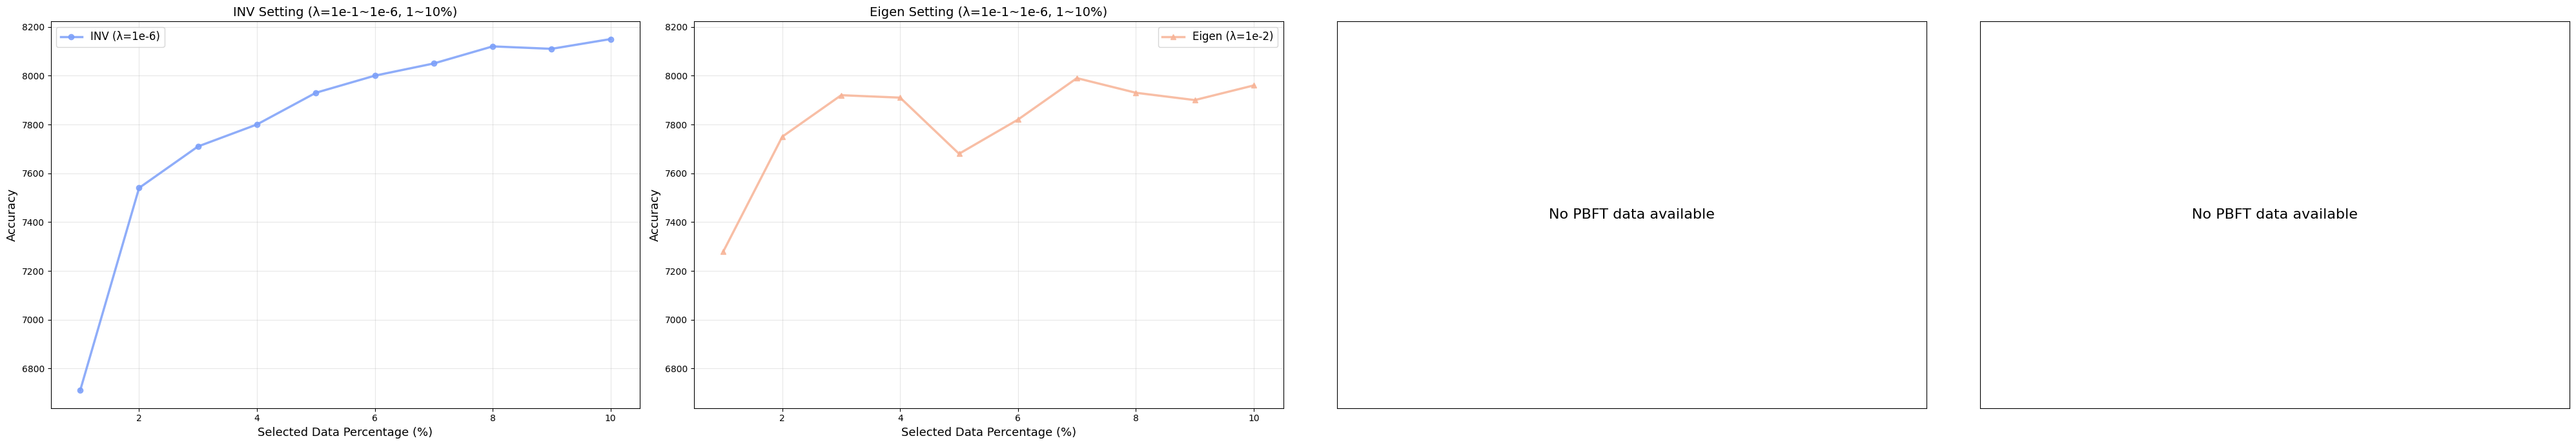

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
rank = 10
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [6710, 7540, 7710, 7800, 7930, 8000, 8050, 8120, 8110, 8150, 8180, 8180, 8240, 8190, 8270, 8250, 8250, 8280, 8270, 8310, 8320, 8360, 8310, 8350, 8390, 8360, 8420, 8400, 8460, 8460, 8490, 8470, 8410, 8410, 8460, 8470, 8450, 8470, 8420, 8450, 8480, 8480, 8480, 8470, 8470, 8460, 8480, 8490, 8520, 8470, 8500, 8530, 8510, 8510, 8550, 8560, 8550, 8570, 8560, 8550, 8530, 8510, 8510, 8520, 8520, 8550, 8520, 8520, 8530, 8550, 8490, 8500, 8530, 8520, 8540, 8500, 8500, 8500, 8480, 8430, 8500, 8480, 8430, 8450, 8400, 8450, 8410, 8400, 8340, 8310, 8270, 8300, 8210, 8230, 8200, 8140, 8160, 8170, 8140, 8070]
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [7280, 7750, 7920, 7910, 7680, 7820, 7990, 7930, 7900, 7960, 8110, 8040, 8080, 8060, 8120, 8110, 8160, 8140, 8110, 8110, 8080, 8150, 8230, 8220, 8200, 8250, 8300, 8310, 8350, 8350, 8360, 8300, 8370, 8370, 8390, 8350, 8420, 8420, 8400, 8400, 8400, 8370, 8340, 8330, 8310, 8330, 8310, 8360, 8320, 8330, 8360, 8340, 8310, 8300, 8370, 8340, 8380, 8390, 8410, 8400, 8390, 8370, 8380, 8390, 8370, 8370, 8330, 8360, 8370, 8420, 8410, 8450, 8450, 8430, 8410, 8420, 8400, 8420, 8400, 8390, 8360, 8360, 8360, 8360, 8350, 8340, 8340, 8350, 8330, 8330, 8310, 8320, 8330, 8320, 8280, 8250, 8260, 8240, 8200, 8140]   
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [5430, 6480, 7260, 7380, 7310, 7430, 7090, 7370, 7510, 7470, 7520, 7510, 7630, 7740, 7680, 7750, 7860, 7880, 7940, 7880, 7800, 7750, 7810, 7860, 7860, 8000, 7930, 7880, 7960, 7940, 7860, 7890, 7850, 7870, 7810, 7880, 7890, 7920, 7820, 7980, 7960, 7890, 7950, 7900, 7880, 7910, 7930, 7990, 7970, 7960, 7960, 7910, 7900, 7940, 7960, 7960, 7920, 7950, 7930, 7990, 7960, 7980, 8000, 7910, 7920, 7900, 7950, 8030, 8000, 7970, 8010, 8030, 8100, 8140, 8120, 8150, 8070, 8070, 8050, 8140, 8070, 8080, 8100, 8090, 8110, 8080, 8090, 8090, 8090, 8080, 8110, 8080, 8020, 8070, 8020, 8040, 8070, 8100, 8070, 8070]  
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [5670, 6240, 7120, 7150, 6810, 6810, 6440, 6550, 6710, 6840, 6760, 6780, 6740, 7100, 7060, 7190, 7340, 7510, 7530, 7530, 7510, 7580, 7570, 7670, 7660, 7660, 7790, 7710, 7820, 7840, 7830, 7860, 7870, 7890, 7830, 7900, 7950, 7960, 7980, 7970, 7970, 7910, 8030, 7980, 7960, 8070, 8060, 8100, 8080, 8100, 8070, 8060, 8070, 8050, 8090, 8040, 8030, 8100, 8090, 8040, 8130, 8110, 8210, 8170, 8170, 8130, 8100, 8160, 8150, 8180, 8200, 8250, 8240, 8200, 8210, 8200, 8220, 8190, 8200, 8210, 8140, 8160, 8160, 8120, 8140, 8130, 8140, 8140, 8140, 8110, 8100, 8110, 8110, 8130, 8150, 8150, 8160, 8160, 8160, 8140]  
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

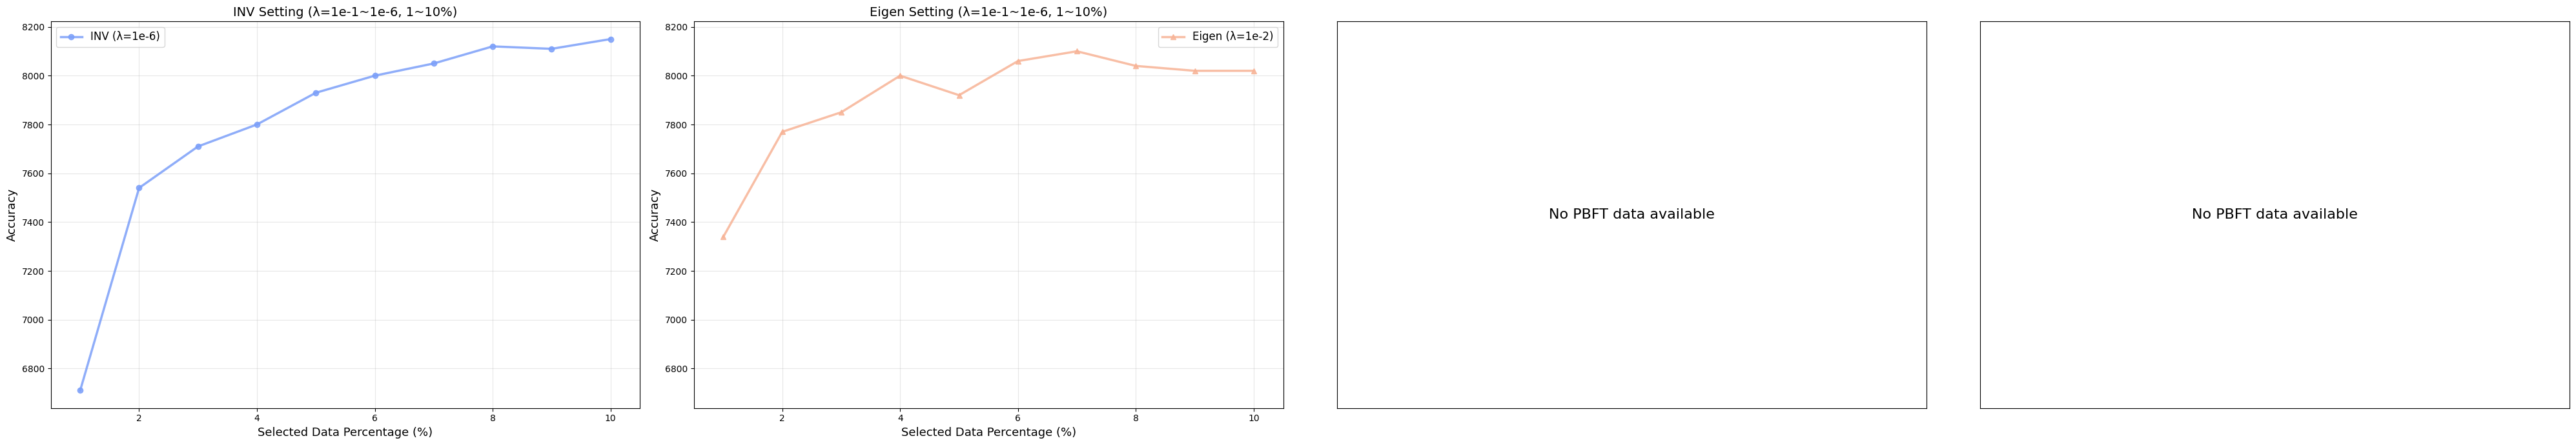

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
rank = 20
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [6710, 7540, 7710, 7800, 7930, 8000, 8050, 8120, 8110, 8150, 8180, 8180, 8240, 8190, 8270, 8250, 8250, 8280, 8270, 8310, 8320, 8360, 8310, 8350, 8390, 8360, 8420, 8400, 8460, 8460, 8490, 8470, 8410, 8410, 8460, 8470, 8450, 8470, 8420, 8450, 8480, 8480, 8480, 8470, 8470, 8460, 8480, 8490, 8520, 8470, 8500, 8530, 8510, 8510, 8550, 8560, 8550, 8570, 8560, 8550, 8530, 8510, 8510, 8520, 8520, 8550, 8520, 8520, 8530, 8550, 8490, 8500, 8530, 8520, 8540, 8500, 8500, 8500, 8480, 8430, 8500, 8480, 8430, 8450, 8400, 8450, 8410, 8400, 8340, 8310, 8270, 8300, 8210, 8230, 8200, 8140, 8160, 8170, 8140, 8070]
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [7340, 7770, 7850, 8000, 7920, 8060, 8100, 8040, 8020, 8020, 8040, 8070, 8260, 8270, 8270, 8270, 8240, 8240, 8290, 8300, 8270, 8370, 8280, 8340, 8290, 8320, 8320, 8320, 8350, 8350, 8380, 8280, 8270, 8300, 8280, 8340, 8350, 8340, 8390, 8380, 8320, 8320, 8310, 8300, 8310, 8290, 8310, 8320, 8310, 8290, 8280, 8300, 8290, 8350, 8370, 8380, 8370, 8360, 8390, 8460, 8430, 8430, 8410, 8420, 8390, 8390, 8390, 8380, 8440, 8400, 8420, 8460, 8440, 8430, 8410, 8420, 8400, 8390, 8400, 8410, 8410, 8400, 8370, 8440, 8330, 8340, 8330, 8350, 8380, 8390, 8360, 8320, 8310, 8320, 8300, 8280, 8280, 8260, 8200, 8190]
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [5430, 6480, 7260, 7380, 7310, 7430, 7090, 7370, 7510, 7470, 7520, 7510, 7630, 7740, 7680, 7750, 7860, 7880, 7940, 7880, 7800, 7750, 7810, 7860, 7860, 8000, 7930, 7880, 7960, 7940, 7860, 7890, 7850, 7870, 7810, 7880, 7890, 7920, 7820, 7980, 7960, 7890, 7950, 7900, 7880, 7910, 7930, 7990, 7970, 7960, 7960, 7910, 7900, 7940, 7960, 7960, 7920, 7950, 7930, 7990, 7960, 7980, 8000, 7910, 7920, 7900, 7950, 8030, 8000, 7970, 8010, 8030, 8100, 8140, 8120, 8150, 8070, 8070, 8050, 8140, 8070, 8080, 8100, 8090, 8110, 8080, 8090, 8090, 8090, 8080, 8110, 8080, 8020, 8070, 8020, 8040, 8070, 8100, 8070, 8070]  
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [5670, 6380, 7170, 7030, 6970, 7020, 6540, 6830, 6980, 7150, 6910, 7060, 6940, 7110, 7060, 7030, 7170, 7220, 7420, 7340, 7170, 7220, 7200, 7370, 7420, 7480, 7480, 7550, 7620, 7630, 7650, 7640, 7620, 7590, 7540, 7510, 7670, 7670, 7650, 7680, 7750, 7790, 7830, 7870, 7850, 7910, 7750, 7830, 7890, 7900, 7940, 7920, 7940, 7910, 7960, 7910, 7950, 8030, 7980, 8090, 8050, 8090, 8040, 7980, 8060, 8110, 8140, 8180, 8160, 8130, 8230, 8190, 8250, 8200, 8190, 8210, 8220, 8190, 8210, 8240, 8200, 8180, 8190, 8160, 8150, 8200, 8180, 8190, 8190, 8220, 8200, 8240, 8260, 8230, 8260, 8230, 8240, 8230, 8180, 8190] 
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

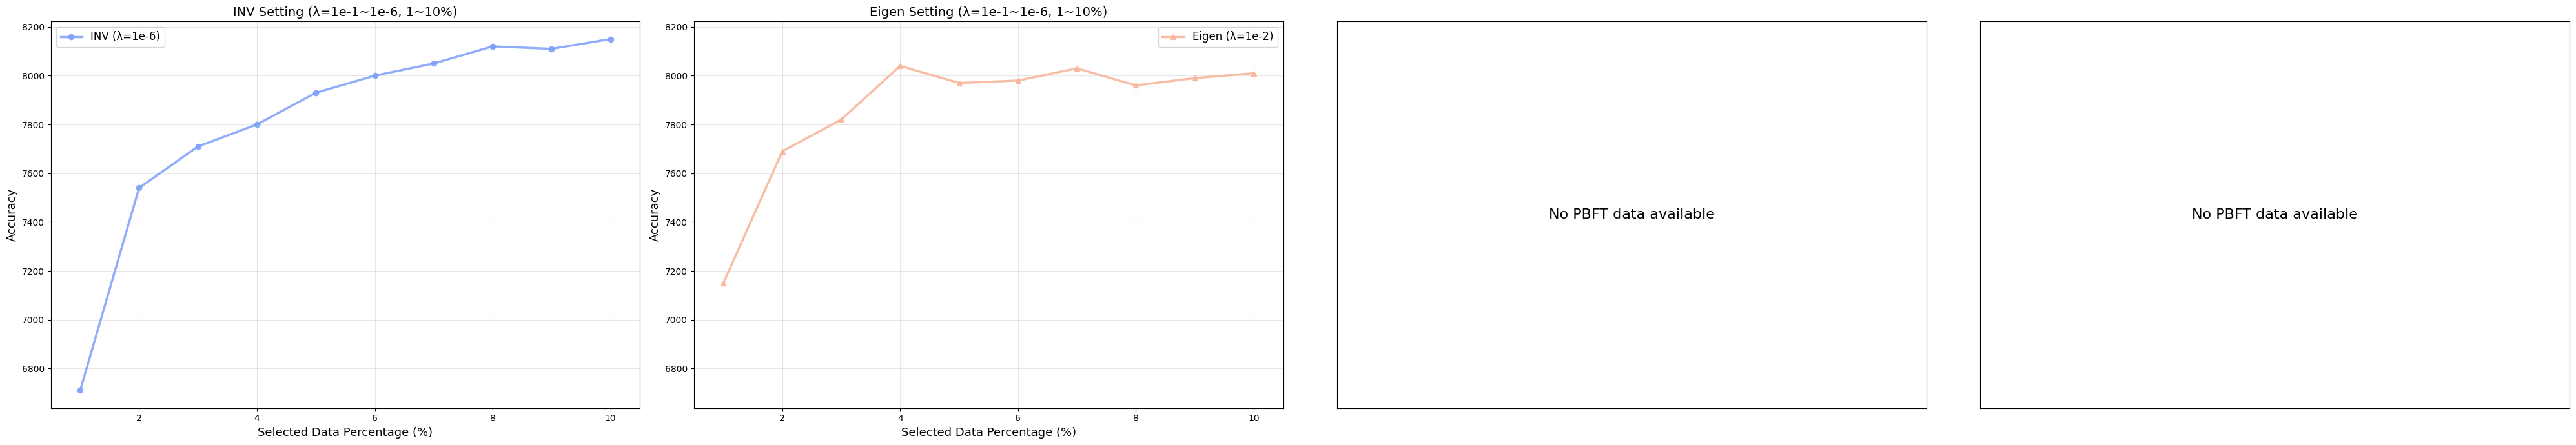

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [6710, 7540, 7710, 7800, 7930, 8000, 8050, 8120, 8110, 8150, 8180, 8180, 8240, 8190, 8270, 8250, 8250, 8280, 8270, 8310, 8320, 8360, 8310, 8350, 8390, 8360, 8420, 8400, 8460, 8460, 8490, 8470, 8410, 8410, 8460, 8470, 8450, 8470, 8420, 8450, 8480, 8480, 8480, 8470, 8470, 8460, 8480, 8490, 8520, 8470, 8500, 8530, 8510, 8510, 8550, 8560, 8550, 8570, 8560, 8550, 8530, 8510, 8510, 8520, 8520, 8550, 8520, 8520, 8530, 8550, 8490, 8500, 8530, 8520, 8540, 8500, 8500, 8500, 8480, 8430, 8500, 8480, 8430, 8450, 8400, 8450, 8410, 8400, 8340, 8310, 8270, 8300, 8210, 8230, 8200, 8140, 8160, 8170, 8140, 8070]
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [7150, 7690, 7820, 8040, 7970, 7980, 8030, 7960, 7990, 8010, 8100, 8140, 8090, 8040, 8060, 8100, 8190, 8190, 8240, 8240, 8250, 8280, 8240, 8220, 8310, 8300, 8340, 8270, 8320, 8330, 8340, 8330, 8310, 8340, 8260, 8200, 8270, 8290, 8320, 8360, 8370, 8380, 8420, 8310, 8380, 8330, 8370, 8360, 8370, 8350, 8390, 8400, 8460, 8440, 8490, 8480, 8400, 8410, 8440, 8380, 8410, 8450, 8400, 8410, 8380, 8400, 8310, 8340, 8400, 8390, 8450, 8510, 8530, 8480, 8440, 8380, 8450, 8370, 8410, 8420, 8370, 8380, 8360, 8380, 8320, 8350, 8360, 8350, 8370, 8370, 8350, 8340, 8340, 8360, 8320, 8270, 8280, 8190, 8200, 8240]  
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [5430, 6480, 7260, 7380, 7310, 7430, 7090, 7370, 7510, 7470, 7520, 7510, 7630, 7740, 7680, 7750, 7860, 7880, 7940, 7880, 7800, 7750, 7810, 7860, 7860, 8000, 7930, 7880, 7960, 7940, 7860, 7890, 7850, 7870, 7810, 7880, 7890, 7920, 7820, 7980, 7960, 7890, 7950, 7900, 7880, 7910, 7930, 7990, 7970, 7960, 7960, 7910, 7900, 7940, 7960, 7960, 7920, 7950, 7930, 7990, 7960, 7980, 8000, 7910, 7920, 7900, 7950, 8030, 8000, 7970, 8010, 8030, 8100, 8140, 8120, 8150, 8070, 8070, 8050, 8140, 8070, 8080, 8100, 8090, 8110, 8080, 8090, 8090, 8090, 8080, 8110, 8080, 8020, 8070, 8020, 8040, 8070, 8100, 8070, 8070]  
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [5600, 6430, 7150, 7210, 7080, 6950, 6790, 7130, 7200, 7110, 7130, 7090, 7100, 7110, 7160, 7360, 7360, 7410, 7510, 7270, 7300, 7220, 7260, 7300, 7360, 7370, 7440, 7490, 7500, 7530, 7490, 7460, 7520, 7560, 7460, 7540, 7540, 7650, 7580, 7730, 7720, 7730, 7850, 7840, 7790, 7810, 7760, 7800, 7900, 7910, 7890, 7910, 7900, 7900, 8000, 7980, 7950, 7990, 7970, 8020, 8060, 8040, 8020, 8070, 8140, 8100, 8140, 8090, 8100, 8130, 8170, 8190, 8260, 8210, 8150, 8180, 8160, 8150, 8220, 8260, 8190, 8220, 8280, 8230, 8280, 8230, 8190, 8230, 8180, 8240, 8230, 8200, 8230, 8240, 8250, 8220, 8250, 8280, 8240, 8240]
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

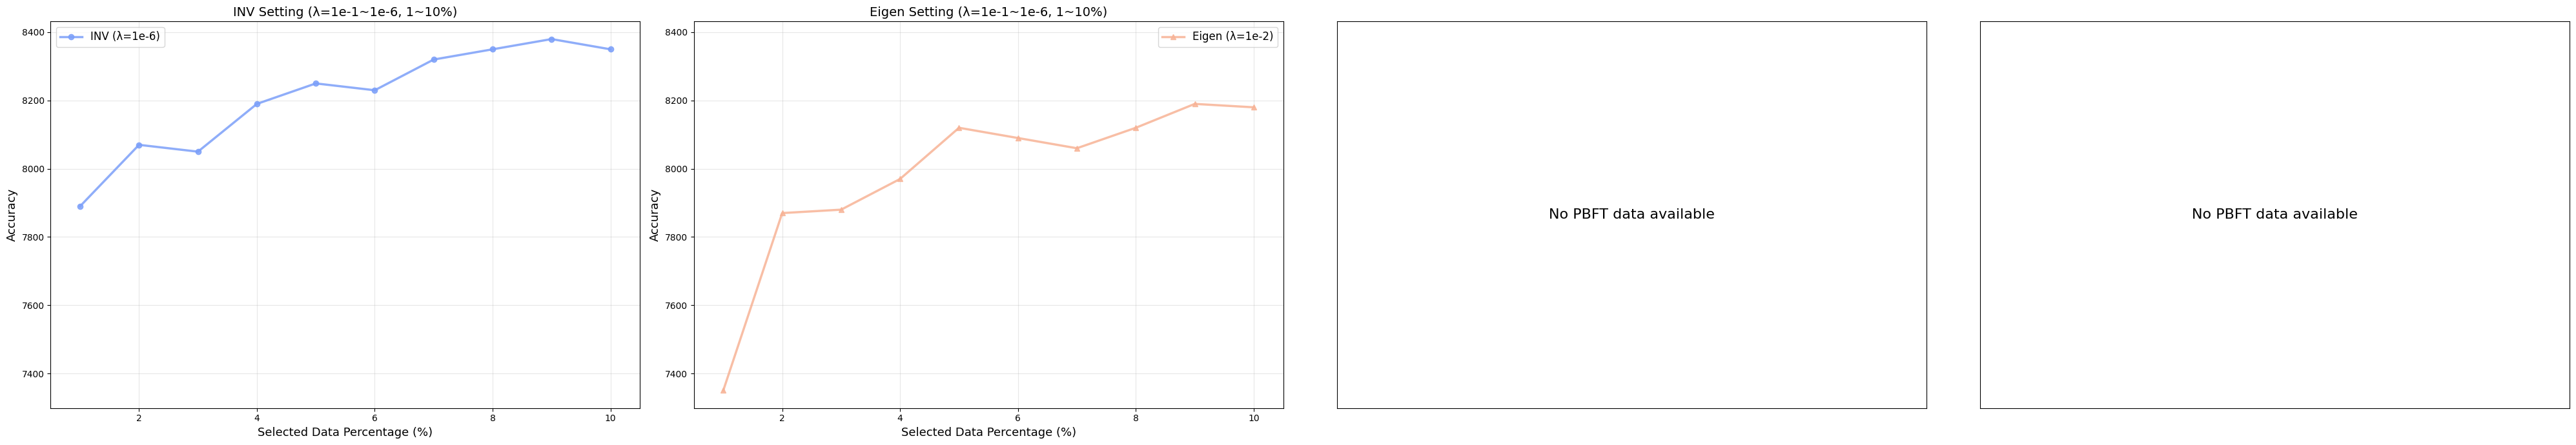

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
rank = 10
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [7890, 8070, 8050, 8190, 8250, 8230, 8320, 8350, 8380, 8350, 8450, 8480, 8480, 8550, 8570, 8590, 8620, 8630, 8600, 8570, 8640, 8620, 8660, 8650, 8640, 8640, 8670, 8650, 8640, 8610, 8630, 8640, 8650, 8650, 8630, 8640, 8650, 8660, 8640, 8670, 8690, 8680, 8710, 8690, 8770, 8720, 8720, 8770, 8740, 8720, 8740, 8720, 8700, 8710, 8710, 8710, 8710, 8670, 8690, 8680, 8700, 8690, 8710, 8700, 8730, 8770, 8730, 8700, 8670, 8670, 8690, 8710, 8670, 8710, 8650, 8660, 8690, 8680, 8710, 8700, 8700, 8700, 8680, 8670, 8690, 8700, 8680, 8640, 8620, 8590, 8570, 8510, 8520, 8560, 8520, 8490, 8460, 8360, 8270, 8130]
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [7350, 7870, 7880, 7970, 8120, 8090, 8060, 8120, 8190, 8180, 8190, 8180, 8230, 8250, 8300, 8290, 8270, 8350, 8390, 8340, 8380, 8350, 8350, 8400, 8390, 8400, 8350, 8410, 8330, 8320, 8380, 8410, 8450, 8440, 8480, 8510, 8450, 8440, 8470, 8470, 8490, 8540, 8530, 8540, 8530, 8500, 8510, 8540, 8530, 8570, 8580, 8580, 8570, 8540, 8570, 8570, 8580, 8550, 8540, 8590, 8590, 8570, 8570, 8590, 8600, 8590, 8580, 8610, 8580, 8580, 8600, 8610, 8560, 8560, 8490, 8520, 8540, 8500, 8490, 8490, 8490, 8480, 8450, 8480, 8440, 8450, 8470, 8460, 8450, 8420, 8460, 8420, 8420, 8420, 8420, 8430, 8380, 8340, 8280, 8250]
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [7290, 7310, 7520, 7630, 7650, 7840, 7850, 7860, 7700, 7820, 7760, 7850, 7700, 7830, 7820, 7880, 7750, 7730, 7810, 7750, 7820, 7910, 7940, 7950, 7810, 7910, 7880, 7880, 7790, 7850, 7900, 7910, 7850, 7890, 7890, 7890, 7920, 8000, 7980, 7990, 8000, 7920, 8000, 8060, 7970, 7950, 8020, 8030, 8040, 8040, 7970, 7960, 8000, 8050, 7900, 7950, 7980, 7970, 8010, 8010, 7970, 7990, 8040, 7990, 7930, 7940, 8000, 7960, 7930, 7930, 7920, 8000, 7950, 7950, 7940, 7910, 7870, 7870, 7920, 7930, 7940, 7870, 7980, 7950, 7990, 7920, 7940, 7970, 7980, 8010, 8040, 8060, 8090, 8110, 8100, 8090, 8110, 8110, 8120, 8130]
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [7020, 7020, 7030, 7140, 7010, 7310, 7360, 7180, 7220, 7410, 7320, 7220, 7180, 7340, 7440, 7370, 7430, 7430, 7560, 7620, 7690, 7760, 7780, 7810, 7820, 7760, 7930, 7890, 7860, 7780, 7800, 7930, 7960, 8020, 8000, 8060, 8060, 8060, 8040, 8090, 8120, 8100, 8100, 8090, 8140, 8080, 8170, 8210, 8200, 8170, 8250, 8260, 8260, 8220, 8270, 8230, 8300, 8320, 8320, 8290, 8320, 8330, 8290, 8240, 8270, 8270, 8300, 8240, 8240, 8230, 8250, 8280, 8270, 8270, 8260, 8270, 8290, 8320, 8270, 8260, 8260, 8240, 8220, 8220, 8220, 8250, 8250, 8240, 8260, 8250, 8260, 8290, 8250, 8270, 8280, 8280, 8240, 8240, 8220, 8250]
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

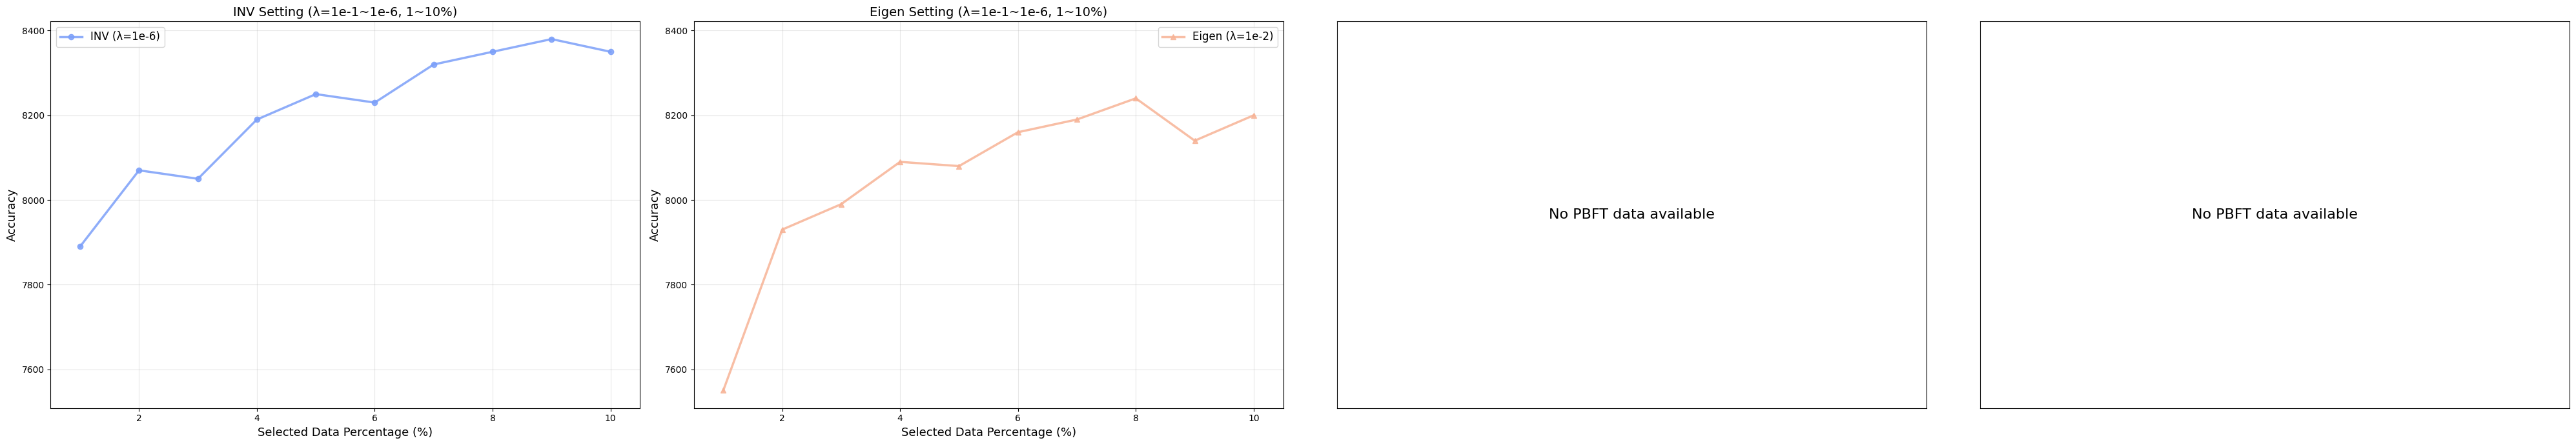

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
rank = 20
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [7890, 8070, 8050, 8190, 8250, 8230, 8320, 8350, 8380, 8350, 8450, 8480, 8480, 8550, 8570, 8590, 8620, 8630, 8600, 8570, 8640, 8620, 8660, 8650, 8640, 8640, 8670, 8650, 8640, 8610, 8630, 8640, 8650, 8650, 8630, 8640, 8650, 8660, 8640, 8670, 8690, 8680, 8710, 8690, 8770, 8720, 8720, 8770, 8740, 8720, 8740, 8720, 8700, 8710, 8710, 8710, 8710, 8670, 8690, 8680, 8700, 8690, 8710, 8700, 8730, 8770, 8730, 8700, 8670, 8670, 8690, 8710, 8670, 8710, 8650, 8660, 8690, 8680, 8710, 8700, 8700, 8700, 8680, 8670, 8690, 8700, 8680, 8640, 8620, 8590, 8570, 8510, 8520, 8560, 8520, 8490, 8460, 8360, 8270, 8130]
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [7550, 7930, 7990, 8090, 8080, 8160, 8190, 8240, 8140, 8200, 8230, 8310, 8260, 8270, 8360, 8400, 8440, 8460, 8530, 8530, 8570, 8510, 8530, 8610, 8560, 8570, 8470, 8460, 8550, 8560, 8600, 8660, 8620, 8630, 8650, 8650, 8680, 8700, 8690, 8720, 8760, 8710, 8740, 8720, 8720, 8730, 8710, 8710, 8760, 8720, 8780, 8750, 8780, 8740, 8780, 8780, 8770, 8720, 8750, 8730, 8710, 8690, 8730, 8740, 8750, 8730, 8720, 8730, 8680, 8650, 8680, 8710, 8700, 8670, 8720, 8730, 8730, 8770, 8740, 8740, 8720, 8690, 8690, 8650, 8660, 8670, 8630, 8610, 8620, 8620, 8550, 8540, 8510, 8570, 8560, 8550, 8510, 8420, 8380, 8310]
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [7290, 7310, 7520, 7630, 7650, 7840, 7850, 7860, 7700, 7820, 7760, 7850, 7700, 7830, 7820, 7880, 7750, 7730, 7810, 7750, 7820, 7910, 7940, 7950, 7810, 7910, 7880, 7880, 7790, 7850, 7900, 7910, 7850, 7890, 7890, 7890, 7920, 8000, 7980, 7990, 8000, 7920, 8000, 8060, 7970, 7950, 8020, 8030, 8040, 8040, 7970, 7960, 8000, 8050, 7900, 7950, 7980, 7970, 8010, 8010, 7970, 7990, 8040, 7990, 7930, 7940, 8000, 7960, 7930, 7930, 7920, 8000, 7950, 7950, 7940, 7910, 7870, 7870, 7920, 7930, 7940, 7870, 7980, 7950, 7990, 7920, 7940, 7970, 7980, 8010, 8040, 8060, 8090, 8110, 8100, 8090, 8110, 8110, 8120, 8130]
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [7120, 7090, 7390, 7400, 7330, 7580, 7670, 7520, 7440, 7430, 7370, 7350, 7350, 7360, 7360, 7330, 7240, 7350, 7290, 7280, 7410, 7410, 7390, 7600, 7560, 7470, 7500, 7530, 7500, 7530, 7500, 7640, 7540, 7740, 7730, 7760, 7700, 7850, 7840, 7800, 7820, 7840, 7910, 7850, 7850, 7860, 7870, 8020, 8020, 8070, 8130, 8110, 8090, 8080, 8090, 8040, 8060, 8150, 8140, 8130, 8150, 8200, 8180, 8190, 8170, 8150, 8180, 8270, 8250, 8240, 8250, 8250, 8230, 8220, 8230, 8250, 8240, 8260, 8210, 8190, 8200, 8280, 8230, 8190, 8230, 8270, 8210, 8210, 8200, 8270, 8260, 8280, 8300, 8270, 8280, 8290, 8250, 8320, 8350, 8310]
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

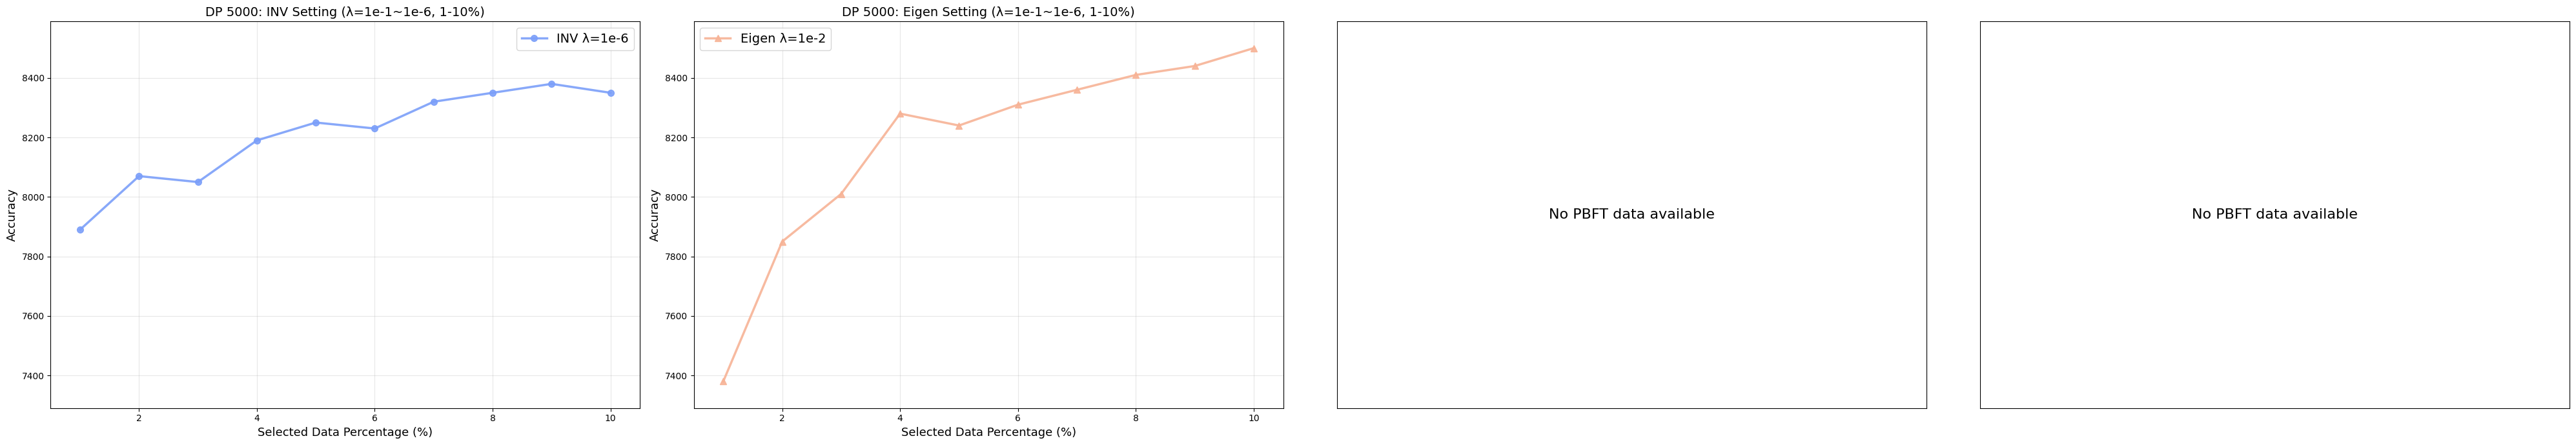

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [7890, 8070, 8050, 8190, 8250, 8230, 8320, 8350, 8380, 8350, 8450, 8480, 8480, 8550, 8570, 8590, 8620, 8630, 8600, 8570, 8640, 8620, 8660, 8650, 8640, 8640, 8670, 8650, 8640, 8610, 8630, 8640, 8650, 8650, 8630, 8640, 8650, 8660, 8640, 8670, 8690, 8680, 8710, 8690, 8770, 8720, 8720, 8770, 8740, 8720, 8740, 8720, 8700, 8710, 8710, 8710, 8710, 8670, 8690, 8680, 8700, 8690, 8710, 8700, 8730, 8770, 8730, 8700, 8670, 8670, 8690, 8710, 8670, 8710, 8650, 8660, 8690, 8680, 8710, 8700, 8700, 8700, 8680, 8670, 8690, 8700, 8680, 8640, 8620, 8590, 8570, 8510, 8520, 8560, 8520, 8490, 8460, 8360, 8270, 8130]
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [7380, 7850, 8010, 8280, 8240, 8310, 8360, 8410, 8440, 8500, 8510, 8590, 8500, 8510, 8570, 8520, 8590, 8640, 8600, 8680, 8630, 8570, 8630, 8530, 8540, 8580, 8610, 8620, 8580, 8610, 8650, 8650, 8650, 8690, 8680, 8710, 8690, 8750, 8750, 8720, 8720, 8710, 8740, 8740, 8700, 8760, 8730, 8770, 8740, 8710, 8770, 8770, 8780, 8810, 8780, 8830, 8850, 8820, 8830, 8830, 8820, 8840, 8810, 8800, 8770, 8740, 8800, 8790, 8820, 8810, 8800, 8800, 8770, 8790, 8810, 8830, 8780, 8770, 8820, 8750, 8820, 8740, 8730, 8740, 8720, 8710, 8680, 8670, 8620, 8640, 8600, 8520, 8580, 8540, 8440, 8490, 8470, 8380, 8370, 8290]
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [7290, 7310, 7520, 7630, 7650, 7840, 7850, 7860, 7700, 7820, 7760, 7850, 7700, 7830, 7820, 7880, 7750, 7730, 7810, 7750, 7820, 7910, 7940, 7950, 7810, 7910, 7880, 7880, 7790, 7850, 7900, 7910, 7850, 7890, 7890, 7890, 7920, 8000, 7980, 7990, 8000, 7920, 8000, 8060, 7970, 7950, 8020, 8030, 8040, 8040, 7970, 7960, 8000, 8050, 7900, 7950, 7980, 7970, 8010, 8010, 7970, 7990, 8040, 7990, 7930, 7940, 8000, 7960, 7930, 7930, 7920, 8000, 7950, 7950, 7940, 7910, 7870, 7870, 7920, 7930, 7940, 7870, 7980, 7950, 7990, 7920, 7940, 7970, 7980, 8010, 8040, 8060, 8090, 8110, 8100, 8090, 8110, 8110, 8120, 8130]
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [7230, 7230, 7380, 7480, 7420, 7670, 7650, 7630, 7530, 7520, 7370, 7410, 7440, 7420, 7430, 7450, 7420, 7300, 7300, 7320, 7440, 7400, 7470, 7510, 7400, 7450, 7440, 7440, 7520, 7530, 7440, 7430, 7330, 7450, 7520, 7510, 7600, 7580, 7600, 7640, 7690, 7690, 7790, 7790, 7800, 7780, 7880, 7820, 7970, 7870, 7910, 7930, 8020, 7950, 7980, 7920, 7990, 7970, 8030, 8000, 7970, 7990, 8000, 8050, 8060, 8100, 8070, 8100, 8160, 8110, 8150, 8180, 8130, 8200, 8180, 8210, 8200, 8230, 8220, 8240, 8180, 8190, 8210, 8190, 8180, 8190, 8150, 8160, 8200, 8230, 8210, 8190, 8180, 8200, 8200, 8250, 8250, 8300, 8300, 8290]
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 red -> 1e-6 blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1 to 1e-6, 1-10%) =====
ax_left = axes[0]

plot_percent = selected_dp_percent[:10]
inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

# Shared y-axis range for (1,1) and (1,2)
shared_series = []
for data, _, _ in inv_lambda_configs + eigen_lambda_configs:
    if data is not None:
        shared_series.extend(data[:10])

if shared_series:
    y_min, y_max = min(shared_series), max(shared_series)
    y_pad = max(20, (y_max - y_min) * 0.08)
else:
    y_min, y_max, y_pad = 0, 1, 0

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(plot_percent, data[:10],
                     color=lambda_colors[i], linewidth=2.5, linestyle='-',
                     marker=marker, markersize=7,
                     label=f'INV λ={lam_label}', alpha=0.9)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ=1e-1~1e-6, 1-10%)', fontsize=14)
ax_left.legend(fontsize=14, loc='best')
ax_left.grid(True, alpha=0.3)
ax_left.set_xlim(0.5, 10.5)
if shared_series:
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)

# ===== Subplot (1,2): Eigen setting (λ=1e-1 to 1e-6, 1-10%) =====
ax_middle = axes[1]

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(plot_percent, data[:10],
                       color=lambda_colors[i], linewidth=2.5, linestyle='-',
                       marker=marker, markersize=7,
                       label=f'Eigen λ={lam_label}', alpha=0.9)

ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ=1e-1~1e-6, 1-10%)', fontsize=14)
ax_middle.legend(fontsize=14, loc='best')
ax_middle.grid(True, alpha=0.3)
ax_middle.set_xlim(0.5, 10.5)
if shared_series:
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

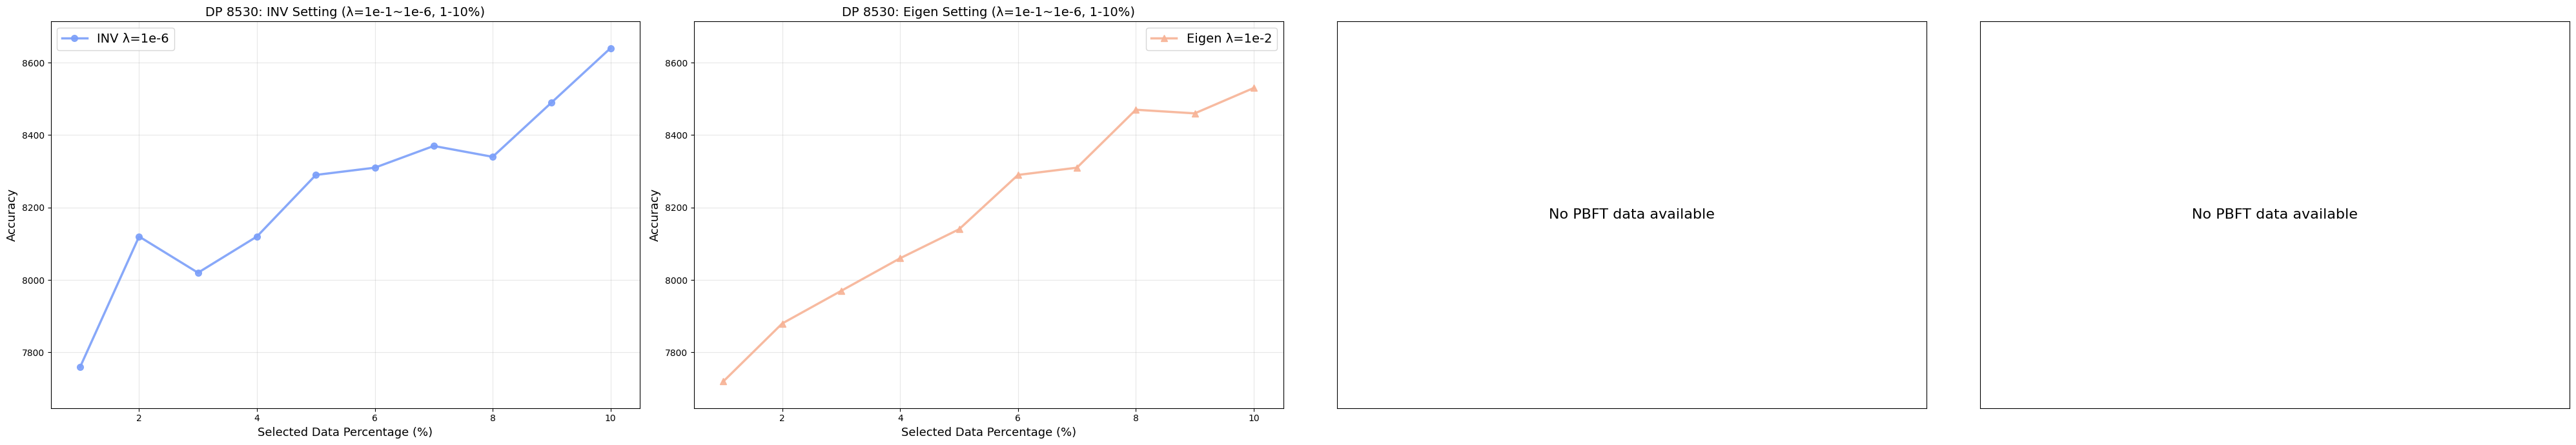

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 8530
rank = 10
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [7760, 8120, 8020, 8120, 8290, 8310, 8370, 8340, 8490, 8640, 8680, 8710, 8790, 8800, 8850, 8880, 8890, 8890, 8870, 8880, 8910, 8870, 8850, 8910, 8920, 8940, 8970, 9000, 9020, 8960, 9000, 9000, 8980, 8990, 8970, 8970 , 9010, 8930, 8910, 8970, 9010, 9030, 9020, 9020, 9020, 8970, 8980, 8940, 8980, 8990, 8980, 9020, 9020, 9050, 8990, 9010, 9020, 8970, 8990, 8980, 8980, 8980, 8990, 9010, 8960, 8970, 8980, 8960, 8940, 8970, 8980, 8980, 8970, 9000, 8910, 8920, 8920, 8920, 8940, 8940, 8930, 8920, 8910, 8860, 8870, 8820, 8860, 8840, 8830, 8790, 8770 , 8770, 8670, 8670, 8610, 8530, 8550, 8470, 8390, 8230]
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [7720, 7880, 7970, 8060, 8140, 8290, 8310, 8470, 8460, 8530, 8490, 8520, 8580, 8580, 8640, 8670, 8700, 8720, 8750, 8740, 8790, 8770, 8770, 8780, 8810, 8820, 8790, 8840, 8810, 8800, 8790, 8820, 8820, 8810, 8810, 8790 , 8800, 8820, 8800, 8820, 8790, 8780, 8790, 8770, 8820, 8810, 8780, 8790, 8800, 8820, 8810, 8790, 8760, 8750, 8720, 8740, 8740, 8720, 8710, 8740, 8750, 8760, 8750, 8760, 8750, 8810, 8780, 8790, 8750, 8780, 8790, 8760, 8760, 8750, 8740, 8790, 8790, 8770, 8790, 8790, 8750, 8770, 8740, 8730, 8760, 8720, 8730, 8710, 8670, 8670, 8670 , 8650, 8610, 8550, 8570, 8480, 8510, 8480, 8360, 8280]
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [7210, 7560, 7630, 7780, 7650, 7810, 7750, 7760, 7890, 7820, 7920, 7890, 7930, 7930, 7910, 7860, 7910, 7910, 7970, 7950, 7930, 7980, 7910, 7950, 7940, 7910, 7950, 7860, 7950, 7980, 8010, 8070, 8070, 7980, 7980, 8040, 7960, 7990, 8030, 8000, 8070, 8080, 7990, 8060, 8130, 8100, 8070, 8090, 8060, 8080, 8120, 8040, 8100, 8150, 8200, 8220, 8280, 8230, 8210, 8270, 8190, 8280, 8250, 8240, 8220, 8270, 8290, 8290, 8260, 8240, 8260, 8150, 8160, 8200, 8150, 8160, 8140, 8160, 8120, 8190, 8210, 8230, 8190, 8200, 8150, 8200, 8210, 8180, 8200, 8230, 8270, 8270, 8280, 8250, 8190, 8230, 8240, 8200, 8300, 8230]
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [6900, 7280, 7160, 7300, 7280, 7160, 7180, 7510, 7280, 7400, 7570, 7590, 7450, 7480, 7480, 7600, 7750, 7870, 7810, 7840, 7830, 7840, 7860, 7870, 7870, 7830, 7970, 7930, 8070, 8060, 8050, 8150, 8100, 8070, 8040, 8100, 8130, 8110, 8030, 8090, 8140, 8090, 8040, 8120, 8110, 8160, 8120, 8190, 8210, 8180, 8210, 8240, 8170, 8180, 8220, 8280, 8290, 8310, 8280, 8220, 8260, 8320, 8270, 8310, 8220, 8280, 8290, 8280, 8270, 8290, 8290, 8310, 8270, 8310, 8320, 8320, 8340, 8310, 8270, 8320, 8290, 8360, 8330, 8330, 8300, 8280, 8270, 8310, 8280, 8270, 8270, 8220, 8220, 8240, 8290, 8310, 8260, 8310, 8280, 8280] 
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 red -> 1e-6 blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1 to 1e-6, 1-10%) =====
ax_left = axes[0]

plot_percent = selected_dp_percent[:10]
inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

# Shared y-axis range for (1,1) and (1,2)
shared_series = []
for data, _, _ in inv_lambda_configs + eigen_lambda_configs:
    if data is not None:
        shared_series.extend(data[:10])

if shared_series:
    y_min, y_max = min(shared_series), max(shared_series)
    y_pad = max(20, (y_max - y_min) * 0.08)
else:
    y_min, y_max, y_pad = 0, 1, 0

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(plot_percent, data[:10],
                     color=lambda_colors[i], linewidth=2.5, linestyle='-',
                     marker=marker, markersize=7,
                     label=f'INV λ={lam_label}', alpha=0.9)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ=1e-1~1e-6, 1-10%)', fontsize=14)
ax_left.legend(fontsize=14, loc='best')
ax_left.grid(True, alpha=0.3)
ax_left.set_xlim(0.5, 10.5)
if shared_series:
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)

# ===== Subplot (1,2): Eigen setting (λ=1e-1 to 1e-6, 1-10%) =====
ax_middle = axes[1]

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(plot_percent, data[:10],
                       color=lambda_colors[i], linewidth=2.5, linestyle='-',
                       marker=marker, markersize=7,
                       label=f'Eigen λ={lam_label}', alpha=0.9)

ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ=1e-1~1e-6, 1-10%)', fontsize=14)
ax_middle.legend(fontsize=14, loc='best')
ax_middle.grid(True, alpha=0.3)
ax_middle.set_xlim(0.5, 10.5)
if shared_series:
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

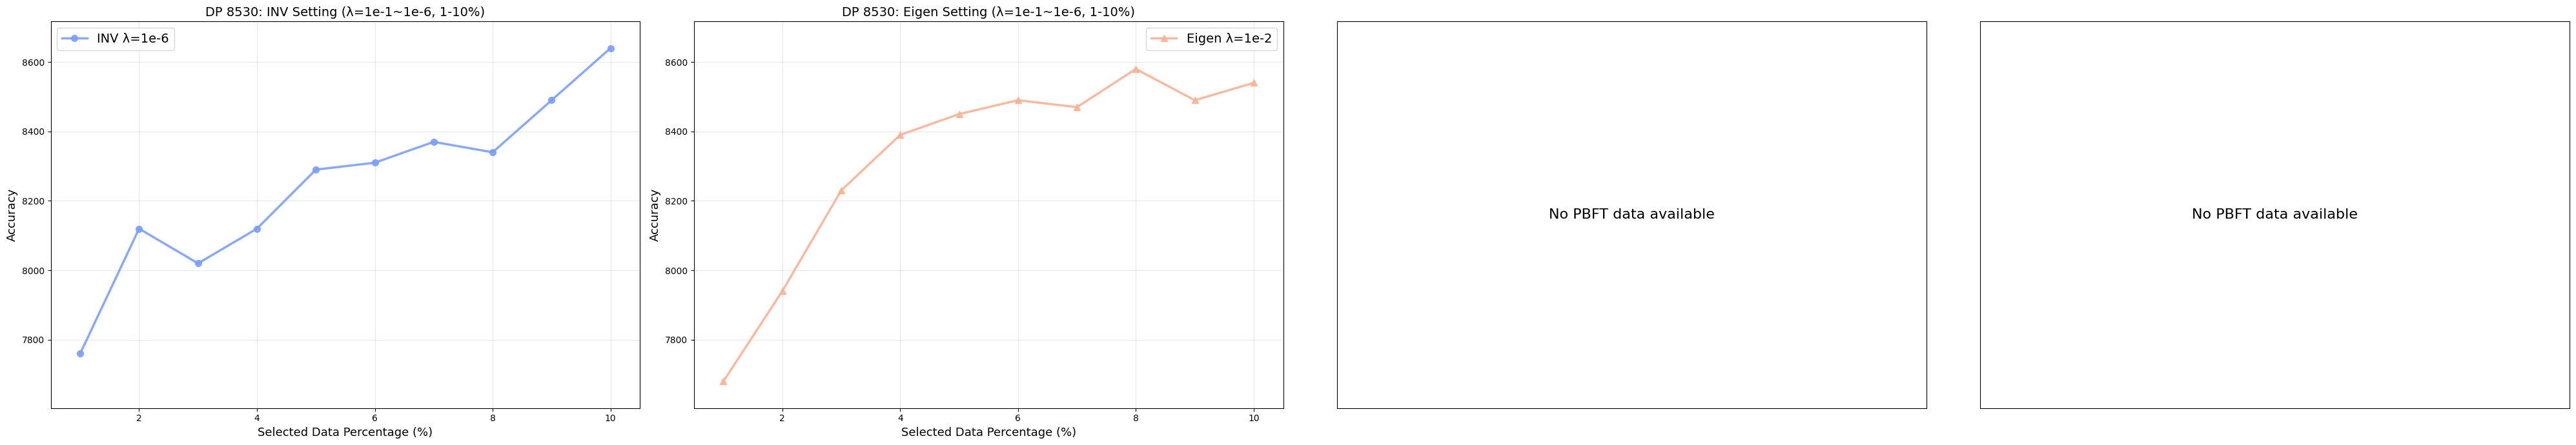

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 8530
rank = 20
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [7760, 8120, 8020, 8120, 8290, 8310, 8370, 8340, 8490, 8640, 8680, 8710, 8790, 8800, 8850, 8880, 8890, 8890, 8870, 8880, 8910, 8870, 8850, 8910, 8920, 8940, 8970, 9000, 9020, 8960, 9000, 9000, 8980, 8990, 8970, 8970 , 9010, 8930, 8910, 8970, 9010, 9030, 9020, 9020, 9020, 8970, 8980, 8940, 8980, 8990, 8980, 9020, 9020, 9050, 8990, 9010, 9020, 8970, 8990, 8980, 8980, 8980, 8990, 9010, 8960, 8970, 8980, 8960, 8940, 8970, 8980, 8980, 8970, 9000, 8910, 8920, 8920, 8920, 8940, 8940, 8930, 8920, 8910, 8860, 8870, 8820, 8860, 8840, 8830, 8790, 8770, 8770, 8670, 8670, 8610, 8530, 8550, 8470, 8390, 8230]
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [7680, 7940, 8230, 8390, 8450, 8490, 8470, 8580, 8490, 8540, 8580, 8610, 8690, 8740, 8780, 8730, 8840, 8830, 8780, 8800, 8850, 8810, 8860, 8890, 8910, 8890, 8900, 8920, 8970, 8960, 8960, 8960, 9020, 9000, 9030, 8980, 8980, 8950, 8980, 8970, 8990, 8960, 8950, 8990, 8960, 8940, 8950, 8970, 8950, 8950, 8920, 8920, 8920, 8920, 8920, 8940, 8900, 8940, 8960, 8930, 8950, 8950, 8980, 8990, 9000, 8990, 8990, 8970, 8950, 8990, 8970, 8950, 8920, 8940, 8910, 8930, 8950, 8960, 8940, 8970, 8950, 8960, 8930, 8910, 8880, 8900, 8890, 8840, 8840, 8870, 8820, 8760, 8720, 8700, 8640, 8600, 8560, 8520, 8460, 8410] 
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [7210, 7560, 7630, 7780, 7650, 7810, 7750, 7760, 7890, 7820, 7920, 7890, 7930, 7930, 7910, 7860, 7910, 7910, 7970, 7950, 7930, 7980, 7910, 7950, 7940, 7910, 7950, 7860, 7950, 7980, 8010, 8070, 8070, 7980, 7980, 8040, 7960, 7990, 8030, 8000, 8070, 8080, 7990, 8060, 8130, 8100, 8070, 8090, 8060, 8080, 8120, 8040, 8100, 8150, 8200, 8220, 8280, 8230, 8210, 8270, 8190, 8280, 8250, 8240, 8220, 8270, 8290, 8290, 8260, 8240, 8260, 8150, 8160, 8200, 8150, 8160, 8140, 8160, 8120, 8190, 8210, 8230, 8190, 8200, 8150, 8200, 8210, 8180, 8200, 8230, 8270, 8270, 8280, 8250, 8190, 8230, 8240, 8200, 8300, 8230]
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [7000, 7420, 7350, 7480, 7450, 7460, 7510, 7560, 7530, 7520, 7490, 7470, 7360, 7460, 7380, 7400, 7440, 7470, 7530, 7490, 7580, 7520, 7590, 7590, 7340, 7500, 7610, 7620, 7550, 7600, 7620, 7660, 7690, 7670, 7720, 7800, 7770, 7820, 7790, 7870, 7890, 7950, 7950, 7940, 7920, 7990, 7970, 8040, 8070, 8050, 8070, 8100, 8070, 8100, 8210, 8240, 8230, 8240, 8200, 8280, 8300, 8290, 8340, 8390, 8330, 8340, 8280, 8340, 8300, 8340, 8330, 8280, 8290, 8300, 8310, 8330, 8370, 8320, 8330, 8330, 8290, 8310, 8350, 8350, 8280, 8270, 8270, 8270, 8280, 8240, 8290, 8330, 8330, 8320, 8340, 8380, 8340, 8390, 8410, 8410]
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 red -> 1e-6 blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1 to 1e-6, 1-10%) =====
ax_left = axes[0]

plot_percent = selected_dp_percent[:10]
inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

# Shared y-axis range for (1,1) and (1,2)
shared_series = []
for data, _, _ in inv_lambda_configs + eigen_lambda_configs:
    if data is not None:
        shared_series.extend(data[:10])

if shared_series:
    y_min, y_max = min(shared_series), max(shared_series)
    y_pad = max(20, (y_max - y_min) * 0.08)
else:
    y_min, y_max, y_pad = 0, 1, 0

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(plot_percent, data[:10],
                     color=lambda_colors[i], linewidth=2.5, linestyle='-',
                     marker=marker, markersize=7,
                     label=f'INV λ={lam_label}', alpha=0.9)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ=1e-1~1e-6, 1-10%)', fontsize=14)
ax_left.legend(fontsize=14, loc='best')
ax_left.grid(True, alpha=0.3)
ax_left.set_xlim(0.5, 10.5)
if shared_series:
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)

# ===== Subplot (1,2): Eigen setting (λ=1e-1 to 1e-6, 1-10%) =====
ax_middle = axes[1]

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(plot_percent, data[:10],
                       color=lambda_colors[i], linewidth=2.5, linestyle='-',
                       marker=marker, markersize=7,
                       label=f'Eigen λ={lam_label}', alpha=0.9)

ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ=1e-1~1e-6, 1-10%)', fontsize=14)
ax_middle.legend(fontsize=14, loc='best')
ax_middle.grid(True, alpha=0.3)
ax_middle.set_xlim(0.5, 10.5)
if shared_series:
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

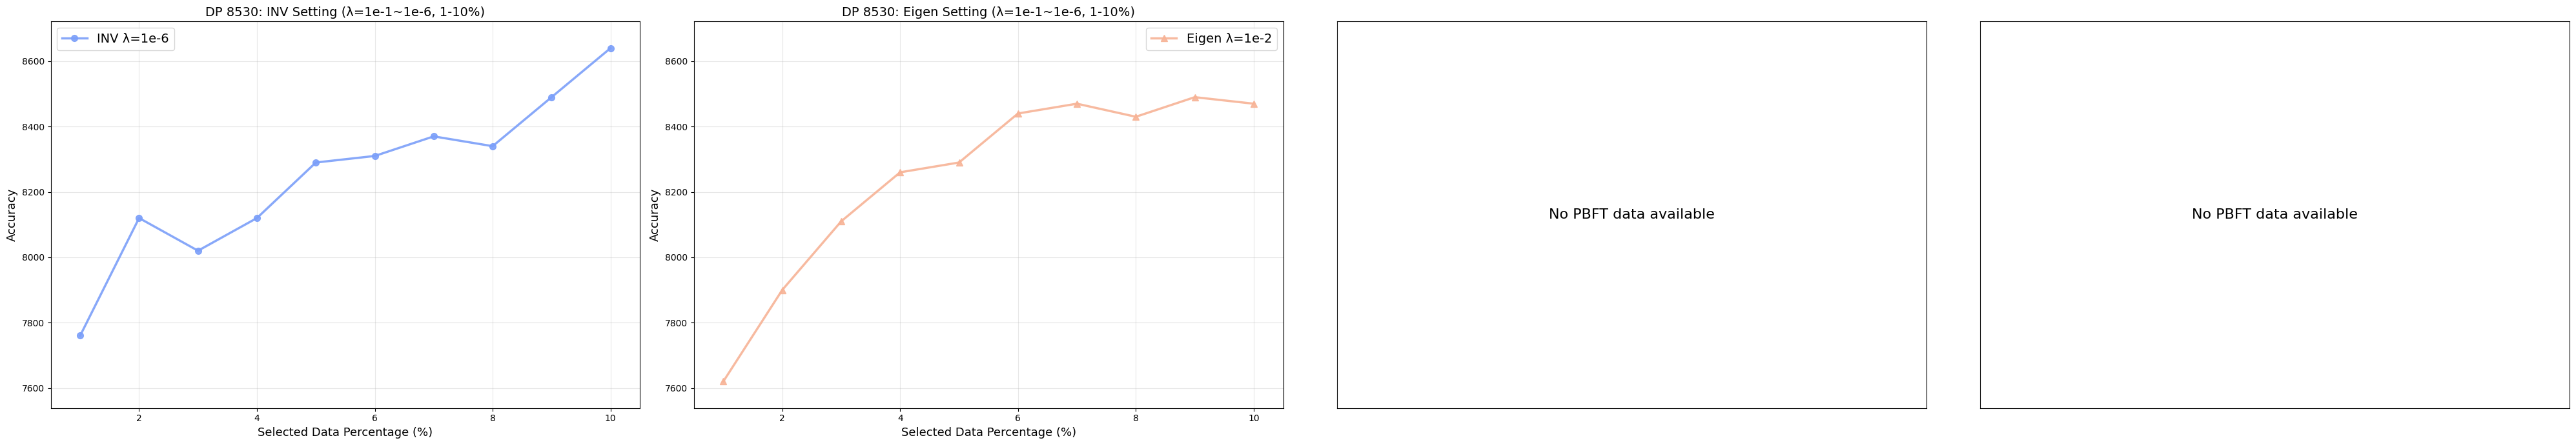

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 8530
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [7760, 8120, 8020, 8120, 8290, 8310, 8370, 8340, 8490, 8640, 8680, 8710, 8790, 8800, 8850, 8880, 8890, 8890, 8870, 8880, 8910, 8870, 8850, 8910, 8920, 8940, 8970, 9000, 9020, 8960, 9000, 9000, 8980, 8990, 8970, 8970, 9010, 8930, 8910, 8970, 9010, 9030, 9020, 9020, 9020, 8970, 8980, 8940, 8980, 8990, 8980, 9020, 9020, 9050, 8990, 9010, 9020, 8970, 8990, 8980, 8980, 8980, 8990, 9010, 8960, 8970, 8980, 8960, 8940, 8970, 8980, 8980, 8970, 9000, 8910, 8920, 8920, 8920, 8940, 8940, 8930, 8920, 8910, 8860, 8870, 8820, 8860, 8840, 8830, 8790, 8770 , 8770, 8670, 8670, 8610, 8530, 8550, 8470, 8390, 8230]
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [7620, 7900, 8110, 8260, 8290, 8440, 8470, 8430, 8490, 8470, 8580, 8560, 8560, 8540, 8680, 8750, 8670, 8720, 8760, 8850, 8810, 8900, 8870, 8870, 8900, 8810, 8870, 8850, 8840, 8920, 8930, 8900, 8910, 8930, 8950, 8980, 8950, 8900, 8930, 8950, 8980, 8970, 8960, 8980, 9040, 9000, 8980, 9000, 9010, 9010, 9000, 9040, 9020, 9000, 8970, 9000, 8990, 9040, 9030, 8980, 8990, 9010, 8990, 8990, 9030, 8960, 8980, 8970, 8990, 8980, 8970, 8940, 8950, 8970, 8940, 8970, 8950, 8960, 8980, 8950, 8950, 8940, 8890, 8940, 8910, 8880, 8840, 8840, 8770, 8750, 8690, 8710, 8650, 8630, 8560, 8570, 8570, 8450, 8360, 8240]
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [7210, 7560, 7630, 7780, 7650, 7810, 7750, 7760, 7890, 7820, 7920, 7890, 7930, 7930, 7910, 7860, 7910, 7910, 7970, 7950, 7930, 7980, 7910, 7950, 7940, 7910, 7950, 7860, 7950, 7980, 8010, 8070, 8070, 7980, 7980, 8040, 7960, 7990, 8030, 8000, 8070, 8080, 7990, 8060, 8130, 8100, 8070, 8090, 8060, 8080, 8120, 8040, 8100, 8150, 8200, 8220, 8280, 8230, 8210, 8270, 8190, 8280, 8250, 8240, 8220, 8270, 8290, 8290, 8260, 8240, 8260, 8150, 8160, 8200, 8150, 8160, 8140, 8160, 8120, 8190, 8210, 8230, 8190, 8200, 8150, 8200, 8210, 8180, 8200, 8230, 8270, 8270, 8280, 8250, 8190, 8230, 8240, 8200, 8300, 8230]
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [7060, 7370, 7440, 7600, 7430, 7530, 7470, 7660, 7670, 7630, 7560, 7590, 7510, 7600, 7520, 7470, 7540, 7600, 7660, 7540, 7630, 7540, 7510, 7580, 7600, 7560, 7680, 7530, 7680, 7730, 7750, 7690, 7840, 7810, 7820, 7840, 7830, 7850, 7830, 7770, 7850, 7950, 7880, 7900, 7950, 8010, 8030, 8030, 8020, 8020, 8010, 8060, 8090, 8080, 8080, 8120, 8120, 8190, 8180, 8120, 8230, 8230, 8250, 8220, 8210, 8280, 8220, 8210, 8250, 8270, 8250, 8220, 8230, 8200, 8280, 8270, 8270, 8240, 8270, 8290, 8260, 8210, 8220, 8240, 8260, 8210, 8190, 8120, 8200, 8210, 8210, 8230, 8190, 8220, 8200, 8220, 8270, 8270, 8210, 8240]   
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 red -> 1e-6 blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1 to 1e-6, 1-10%) =====
ax_left = axes[0]

plot_percent = selected_dp_percent[:10]
inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

# Shared y-axis range for (1,1) and (1,2)
shared_series = []
for data, _, _ in inv_lambda_configs + eigen_lambda_configs:
    if data is not None:
        shared_series.extend(data[:10])

if shared_series:
    y_min, y_max = min(shared_series), max(shared_series)
    y_pad = max(20, (y_max - y_min) * 0.08)
else:
    y_min, y_max, y_pad = 0, 1, 0

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(plot_percent, data[:10],
                     color=lambda_colors[i], linewidth=2.5, linestyle='-',
                     marker=marker, markersize=7,
                     label=f'INV λ={lam_label}', alpha=0.9)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ=1e-1~1e-6, 1-10%)', fontsize=14)
ax_left.legend(fontsize=14, loc='best')
ax_left.grid(True, alpha=0.3)
ax_left.set_xlim(0.5, 10.5)
if shared_series:
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)

# ===== Subplot (1,2): Eigen setting (λ=1e-1 to 1e-6, 1-10%) =====
ax_middle = axes[1]

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(plot_percent, data[:10],
                       color=lambda_colors[i], linewidth=2.5, linestyle='-',
                       marker=marker, markersize=7,
                       label=f'Eigen λ={lam_label}', alpha=0.9)

ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ=1e-1~1e-6, 1-10%)', fontsize=14)
ax_middle.legend(fontsize=14, loc='best')
ax_middle.grid(True, alpha=0.3)
ax_middle.set_xlim(0.5, 10.5)
if shared_series:
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()